# Techincal Requirements
## Part A: Data Preprocessing Pipeline

Covers all 4 spec requirements:
1.  Text cleaning (imported from EDA)
2.  Tokenisation & vocabulary construction
3.  Encoding & padding
4.  Dataset splitting (70/10/20 stratified)

# Setup: Imports, Helpers & Data

**Part A**: Data preprocessing pipeline (Text cleaning, Tokenization, Encoding, Splitting 70/10/20)

In [4]:

# Import training infrastructure
import sys
sys.path.insert(0, '../src')

from preprocess import DataManager, DataConfig
from mlp_model import MLPClassifier
from train import Trainer, TrainingConfig
from evaluate import MetricsCalculator, Visualizations, ErrorAnalysis
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Part B: MLP Ablation Study")
print("  - Network Depth (1 vs 2 vs 3 layers)")
print("  - Embedding Dimension (64 vs 128 vs 256)")
print("  - Dropout Rate (0.2 vs 0.3 vs 0.5)")


C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Part B: MLP Ablation Study
  - Network Depth (1 vs 2 vs 3 layers)
  - Embedding Dimension (64 vs 128 vs 256)
  - Dropout Rate (0.2 vs 0.3 vs 0.5)


In [5]:

# ============================================================================
# HELPER FUNCTIONS FOR ABLATION STUDY
# ============================================================================

def count_params(model):
    """Count total trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compute_accuracy(model, loader, device):
    """Compute accuracy on a dataset."""
    model.eval()
    preds, labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            token_ids, batch_labels = batch
            token_ids = token_ids.to(device)
            batch_labels = batch_labels.to(device)
            
            logits = model(token_ids)
            batch_preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy().flatten()
            preds.extend(batch_preds)
            labels.extend(batch_labels.cpu().numpy())
    
    return np.mean(np.array(preds) == np.array(labels))


def train_model(config_dict, num_epochs=10, device='cuda', model_save_name=None):
    """
    Train a single MLP model with given configuration.
    
    Args:
        config_dict: Dict with 'embed_dim', 'hidden_dims', 'dropout'
        num_epochs: Number of training epochs
        device: 'cuda' or 'cpu'
        model_save_name: Name to save the model (e.g., 'mlp_depth1')
        
    Returns:
        (history, best_val_loss, test_acc, param_count, trained_model)
    """
    # Initialize model
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=config_dict['embed_dim'],
        hidden_dims=config_dict['hidden_dims'],
        dropout=config_dict['dropout']
    )
    
    n_params = count_params(model)
    
    # Training config
    train_cfg = TrainingConfig(
        epochs=num_epochs,
        learning_rate=0.001,
        weight_decay=1e-5,
        batch_size=64,
        patience=3,
        checkpoint_dir='../checkpoints',
        model_name=f'mlp_experiment'
    )
    
    # Train
    trainer = Trainer(model, train_cfg, device=device)
    train_losses, val_losses = trainer.train(train_loader, val_loader)
    
    # Compute accuracies on train and val sets at the end
    train_acc = compute_accuracy(model, train_loader, device)
    val_acc = compute_accuracy(model, val_loader, device)
    
    # Test evaluation
    test_acc = compute_accuracy(model, test_loader, device)
    
    # Save model if name provided
    if model_save_name:
        model_path = f'../checkpoints/{model_save_name}.pt'
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ Model saved to {model_save_name}.pt")
    
    history = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'best_val_loss': trainer.best_val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc
    }
    
    return history, trainer.best_val_loss, test_acc, n_params, model


def plot_loss_accuracy_curves(histories, title_prefix=''):
    """
    Plot separate curves for loss and accuracy metrics.
    
    Args:
        histories: Dict of model_name -> history dict with loss and accuracy data
        title_prefix: Prefix for plot titles
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(histories)))
    
    # Plot 1: Training Loss
    for (name, hist), color in zip(histories.items(), colors):
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], '--', label=f'{name} (train)', 
                    color=color, linewidth=2, alpha=0.7)
    
    axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Training Loss', fontsize=11, fontweight='bold')
    axes[0].set_title(f'{title_prefix} - Training Loss', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=8, loc='upper right')
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Validation Loss
    for (name, hist), color in zip(histories.items(), colors):
        epochs = range(1, len(hist['val_loss']) + 1)
        axes[1].plot(epochs, hist['val_loss'], '-', label=f'{name}', 
                    color=color, linewidth=2.5)
    
    axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    axes[1].set_title(f'{title_prefix} - Validation Loss', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../results/{title_prefix.lower().replace(" ", "_")}_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def print_results_table(results_dict, title='Results'):
    """Pretty-print results table with accuracy metrics."""
    df = pd.DataFrame(results_dict).T
    df.columns = ['Best Val Loss', 'Test Accuracy', 'Train Acc', 'Val Acc', 'Params']
    df['Params'] = df['Params'].apply(lambda x: f'{int(x):,}')
    df['Best Val Loss'] = df['Best Val Loss'].apply(lambda x: f'{x:.4f}')
    df['Test Accuracy'] = df['Test Accuracy'].apply(lambda x: f'{x:.4f}')
    df['Train Acc'] = df['Train Acc'].apply(lambda x: f'{x:.4f}')
    df['Val Acc'] = df['Val Acc'].apply(lambda x: f'{x:.4f}')
    
    print(f'\n{"="*85}')
    print(f'{title:^85}')
    print(f'{"="*85}')
    print(df.to_string())
    print(f'{"="*85}\n')

print("✓ Helper functions defined")


✓ Helper functions defined


In [6]:

# ============================================================================
# DATA PREPARATION
# ============================================================================

# Prepare data using DataManager from preprocess.py
config = DataConfig(
    max_vocab_size=20_000,
    max_len=256,
    batch_size=64,
    random_state=42
)

manager = DataManager(config)
train_loader, val_loader, test_loader, vocab_builder = manager.prepare()

# Verify device availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n✓ Data loaded. Using device: {device}")
print(f"  Vocabulary size: {len(vocab_builder):,}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Create results directory
Path('../results').mkdir(exist_ok=True)
Path('../checkpoints').mkdir(exist_ok=True)
print("✓ Output directories created")


DATA PREPARATION PIPELINE
Loading IMDb dataset...
  Loaded 50,000 samples
Preprocessing texts...
  Cleaned 50,000 texts
Building vocabulary...
  Vocabulary size: 20,000
Creating DataLoaders...
  Train batches: 547
  Val batches: 79
  Test batches: 157

✓ Data loaded. Using device: cpu
  Vocabulary size: 20,000
  Train batches: 547
  Val batches: 79
  Test batches: 157
✓ Output directories created


In [7]:
print(vocab_builder['<pad>']) 
print(vocab_builder['<unk>'])

0
1


# Part B: MLP Architecture Ablation Study

Three controlled experiments to optimize MLP design:
- **Experiment 1**: Network depth — Compare 1 vs 2 vs 3 hidden layers (equal param count)
- **Experiment 2**: Embedding dimension — Use best from Exp 1, test $d_e \in \{64, 128, 256\}$
- **Experiment 3**: Dropout rate — Use best from Exp 1&2, test $p \in \{0.2, 0.3, 0.5\}$

**Results form the MLP baseline for RNN comparison in Part C**

## Experiment 1: Network Depth

**Goal**: Compare 1 vs 2 vs 3 hidden layers with approximately constant parameter count

**Controlled**: `embed_dim=128`, `dropout=0.3`, learning rate, epochs  
**Variable**: `hidden_dims` (architecture depth)


EXPERIMENT 1: NETWORK DEPTH ANALYSIS

Comparing network architectures with approximately equal parameter counts:
  - Config A: 1 layer   [512]
  - Config B: 2 layers  [256, 256]
  - Config C: 3 layers  [128, 256, 128]

Fixed hyperparameters:
  - embed_dim: 128
  - dropout: 0.3
  - epochs: 10

Parameter Count Verification:
--------------------------------------------------
  1-layer  [512]            →  2,626,561 params
  2-layers [256,256]        →  2,659,073 params
  3-layers [128,256,128]    →  2,642,561 params

----------------------------------------------------------------------
Training depth configurations...
----------------------------------------------------------------------

[Training] 1-layer  [512]
  Config: embed_dim=128, hidden_dims=[512], dropout=0.3

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6619
  Batch [200/547], Loss: 0.6113
  Batch [300/547], Loss: 0.5779
  Batch [400/547], Loss: 0.5457
  Batch [500/547], L

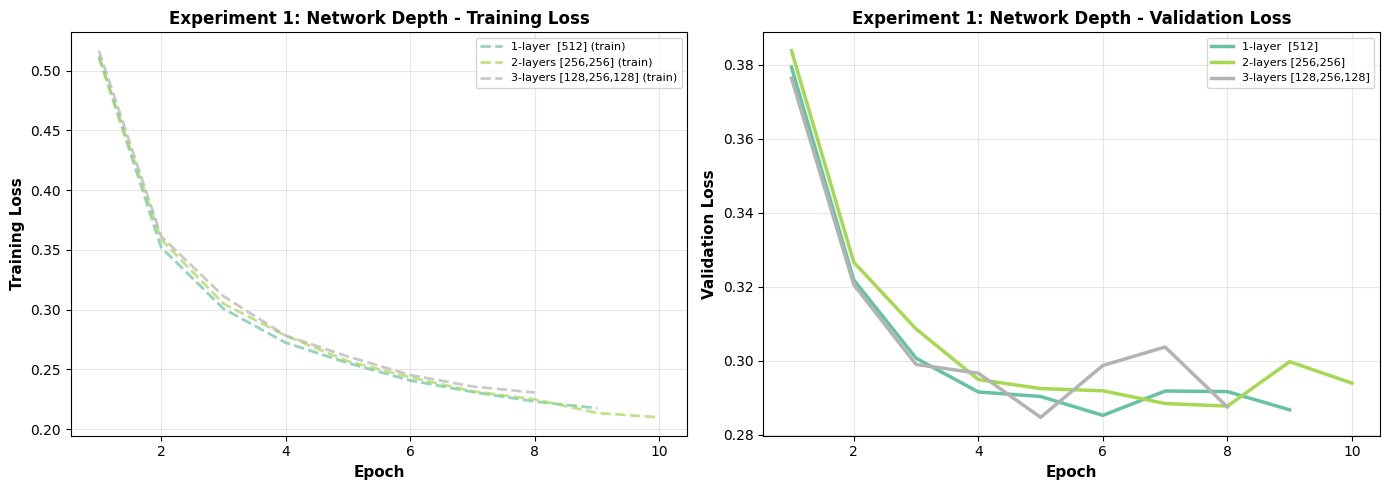


                         EXPERIMENT 1: NETWORK DEPTH RESULTS                         
                       Best Val Loss Test Accuracy Train Acc Val Acc     Params
1-layer  [512]                0.2853        0.8851    0.9469  0.8856  2,626,561
2-layers [256,256]            0.2878        0.8859    0.9513  0.8844  2,659,073
3-layers [128,256,128]        0.2848        0.8848    0.9443  0.8874  2,642,561

✓ Best depth configuration: 3-layers [128,256,128]
  Test Accuracy: 0.8848
  Hidden Dims: [128, 256, 128] (to be used in Experiment 2)
✓ Experiment 1 results persisted to ..\results\ablation_results.pkl


In [ ]:

# ============================================================================
# EXPERIMENT 1: NETWORK DEPTH
# ============================================================================
# Compare 1 vs 2 vs 3 hidden layers with CONSTANT parameter count
# Controlled: embed_dim=128, dropout=0.3

print("\n" + "="*70)
print("EXPERIMENT 1: NETWORK DEPTH ANALYSIS")
print("="*70)
print("\nComparing network architectures with approximately equal parameter counts:")
print("  - Config A: 1 layer   [512]")
print("  - Config B: 2 layers  [256, 256]")
print("  - Config C: 3 layers  [128, 256, 128]")
print("\nFixed hyperparameters:")
print("  - embed_dim: 128")
print("  - dropout: 0.3")
print("  - epochs: 10\n")

# Define configurations with carefully chosen hidden dims to equalize params
depth_configs = {
    '1-layer  [512]':        {'embed_dim': 128, 'hidden_dims': [512],           'dropout': 0.3},
    '2-layers [256,256]':    {'embed_dim': 128, 'hidden_dims': [256, 256],      'dropout': 0.3},
    '3-layers [128,256,128]':{'embed_dim': 128, 'hidden_dims': [128, 256, 128], 'dropout': 0.3},
}

# Display parameter counts before training
print("Parameter Count Verification:")
print("-" * 50)
for name, cfg in depth_configs.items():
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=cfg['embed_dim'],
        hidden_dims=cfg['hidden_dims'],
        dropout=cfg['dropout']
    )
    params = count_params(model)
    print(f"  {name:<25} → {params:>10,} params")

# Train all depth configurations
print("\n" + "-"*70)
print("Training depth configurations...")
print("-"*70)

depth_histories = {}
depth_results = {}
depth_models = {}
NUM_EPOCHS = 10

# Save names for each config
save_names = ['mlp_depth1', 'mlp_depth2', 'mlp_depth3']

for (name, cfg), save_name in zip(depth_configs.items(), save_names):
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params, model = train_model(cfg, num_epochs=NUM_EPOCHS, device=device, model_save_name=save_name)
    
    depth_histories[name] = hist
    depth_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'train_acc': hist['train_acc'],
        'val_acc': hist['val_acc'],
        'params': n_params
    }
    depth_models[name] = model
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}, Train Acc={hist['train_acc']:.4f}, Val Acc={hist['val_acc']:.4f}, Params={n_params:,}")

# Visualize results
plot_loss_accuracy_curves(depth_histories, title_prefix='Experiment 1: Network Depth')

# Print results table
print_results_table(depth_results, title='EXPERIMENT 1: NETWORK DEPTH RESULTS')

# Identify best configuration
best_depth_name = min(depth_results, key=lambda x: depth_results[x]['best_val_loss'])
best_depth_config = depth_configs[best_depth_name]
print(f"✓ Best depth configuration: {best_depth_name}")
print(f"  Test Accuracy: {depth_results[best_depth_name]['test_acc']:.4f}")
print(f"  Hidden Dims: {best_depth_config['hidden_dims']} (to be used in Experiment 2)")

# Persist Experiment 1 results so Summary can load later
import pickle
result_cache_path = Path('../results/ablation_results.pkl')
if result_cache_path.exists():
    with open(result_cache_path, 'rb') as f:
        cache = pickle.load(f)
else:
    cache = {}
cache['depth_results'] = depth_results
cache['best_depth_config'] = best_depth_config
with open(result_cache_path, 'wb') as f:
    pickle.dump(cache, f)
print(f"✓ Experiment 1 results persisted to {result_cache_path}")


## Experiment 2: Embedding Dimension

**Goal**: Find optimal embedding size using the best architecture from Experiment 1

**Controlled**: `hidden_dims` from Exp 1 (best), `dropout=0.3`, learning rate, epochs  
**Variable**: `embed_dim` ∈ {64, 128, 256}


EXPERIMENT 2: EMBEDDING DIMENSION ANALYSIS

Comparing embedding dimensions:
  - d_e = 64   (compact)
  - d_e = 128  (moderate)
  - d_e = 256  (rich, expressive)

Fixed hyperparameters:
  - hidden_dims: [128, 256, 128] (best from Exp 1)
  - dropout: 0.3
  - epochs: 10

Parameter Count Scaling:
--------------------------------------------------
  d_e = 64        →  1,354,369 params
  d_e = 128       →  2,642,561 params
  d_e = 256       →  5,218,945 params

----------------------------------------------------------------------
Training embedding dimension configurations...
----------------------------------------------------------------------

[Training] d_e = 64
  Config: embed_dim=64, hidden_dims=[128, 256, 128], dropout=0.3

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6804
  Batch [200/547], Loss: 0.6441
  Batch [300/547], Loss: 0.6104
  Batch [400/547], Loss: 0.5795
  Batch [500/547], Loss: 0.5589
Epoch [1/10]
  Train Loss: 0.55

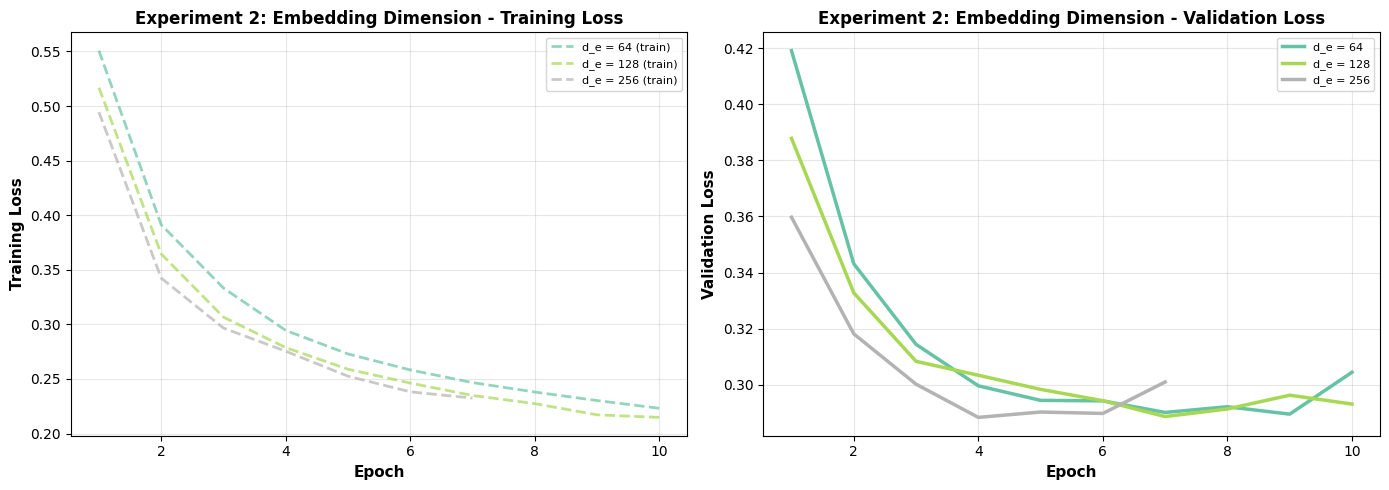


                      EXPERIMENT 2: EMBEDDING DIMENSION RESULTS                      
          Best Val Loss Test Accuracy Train Acc Val Acc     Params
d_e = 64         0.2895        0.8872    0.9453  0.8850  1,354,369
d_e = 128        0.2886        0.8854    0.9511  0.8824  2,642,561
d_e = 256        0.2883        0.8799    0.9407  0.8816  5,218,945

✓ Best embedding dimension: d_e = 256
  Test Accuracy: 0.8799
  Value: 256 (to be used in Experiment 3)
✓ Experiment 2 results persisted to ..\results\ablation_results.pkl


In [9]:

# ============================================================================
# EXPERIMENT 2: EMBEDDING DIMENSION
# ============================================================================
# Use best depth from Exp 1, vary embedding dimension
# Controlled: hidden_dims from Exp 1, dropout=0.3

print("\n" + "="*70)
print("EXPERIMENT 2: EMBEDDING DIMENSION ANALYSIS")
print("="*70)
print("\nComparing embedding dimensions:")
print("  - d_e = 64   (compact)")
print("  - d_e = 128  (moderate)")
print("  - d_e = 256  (rich, expressive)")
print("\nFixed hyperparameters:")
print(f"  - hidden_dims: {best_depth_config['hidden_dims']} (best from Exp 1)")
print("  - dropout: 0.3")
print("  - epochs: 10\n")

# Define embedding dimension configurations
embed_configs = {
    'd_e = 64':  {'embed_dim': 64,  'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'd_e = 128': {'embed_dim': 128, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'd_e = 256': {'embed_dim': 256, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
}

# Display parameter counts before training
print("Parameter Count Scaling:")
print("-" * 50)
for name, cfg in embed_configs.items():
    model = MLPClassifier(
        vocab_size=len(vocab_builder),
        embedding_dim=cfg['embed_dim'],
        hidden_dims=cfg['hidden_dims'],
        dropout=cfg['dropout']
    )
    params = count_params(model)
    print(f"  {name:<15} → {params:>10,} params")

# Train all embedding dimension configurations
print("\n" + "-"*70)
print("Training embedding dimension configurations...")
print("-"*70)

embed_histories = {}
embed_results = {}
embed_models = {}

# Save names for each config
embed_save_names = ['mlp_embed64', 'mlp_embed128', 'mlp_embed256']

for (name, cfg), save_name in zip(embed_configs.items(), embed_save_names):
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params, model = train_model(cfg, num_epochs=NUM_EPOCHS, device=device, model_save_name=save_name)
    
    embed_histories[name] = hist
    embed_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'train_acc': hist['train_acc'],
        'val_acc': hist['val_acc'],
        'params': n_params
    }
    embed_models[name] = model
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}, Train Acc={hist['train_acc']:.4f}, Val Acc={hist['val_acc']:.4f}, Params={n_params:,}")

# Visualize results
plot_loss_accuracy_curves(embed_histories, title_prefix='Experiment 2: Embedding Dimension')

# Print results table
print_results_table(embed_results, title='EXPERIMENT 2: EMBEDDING DIMENSION RESULTS')

# Identify best configuration
best_embed_name = min(embed_results, key=lambda x: embed_results[x]['best_val_loss'])
best_embed_config = embed_configs[best_embed_name]
best_embed_dim = best_embed_config['embed_dim']
print(f"✓ Best embedding dimension: {best_embed_name}")
print(f"  Test Accuracy: {embed_results[best_embed_name]['test_acc']:.4f}")
print(f"  Value: {best_embed_dim} (to be used in Experiment 3)")

# Persist Experiment 2 results so Summary can load later
import pickle
result_cache_path = Path('../results/ablation_results.pkl')
if result_cache_path.exists():
    with open(result_cache_path, 'rb') as f:
        cache = pickle.load(f)
else:
    cache = {}
cache['embed_results'] = embed_results
cache['best_embed_dim'] = best_embed_dim
with open(result_cache_path, 'wb') as f:
    pickle.dump(cache, f)
print(f"✓ Experiment 2 results persisted to {result_cache_path}")


## Experiment 3: Dropout Rate

**Goal**: Analyze regularization effect on overfitting using optimal architecture & embedding

**Controlled**: `hidden_dims` from Exp 1 (best), `embed_dim` from Exp 2 (best), learning rate, epochs  
**Variable**: `dropout` ∈ {0.2, 0.3, 0.5}


EXPERIMENT 3: DROPOUT RATE ANALYSIS

Comparing dropout rates for regularization:
  - p = 0.2 (light regularization)
  - p = 0.3 (moderate regularization)
  - p = 0.5 (heavy regularization)

Fixed hyperparameters:
  - embed_dim: 256 (best from Exp 2)
  - hidden_dims: [128, 256, 128] (best from Exp 1)
  - epochs: 10

Parameter Count (constant across all dropout rates):
--------------------------------------------------
  All configs:  5,218,945 params

----------------------------------------------------------------------
Training dropout configurations...
----------------------------------------------------------------------

[Training] p = 0.2
  Config: embed_dim=256, hidden_dims=[128, 256, 128], dropout=0.2

Training mlp_experiment for 10 epochs
Device: cpu, Learning rate: 0.001
  Batch [100/547], Loss: 0.6449
  Batch [200/547], Loss: 0.5814
  Batch [300/547], Loss: 0.5374
  Batch [400/547], Loss: 0.5049
  Batch [500/547], Loss: 0.4816
Epoch [1/10]
  Train Loss: 0.4730
  Val Loss:   

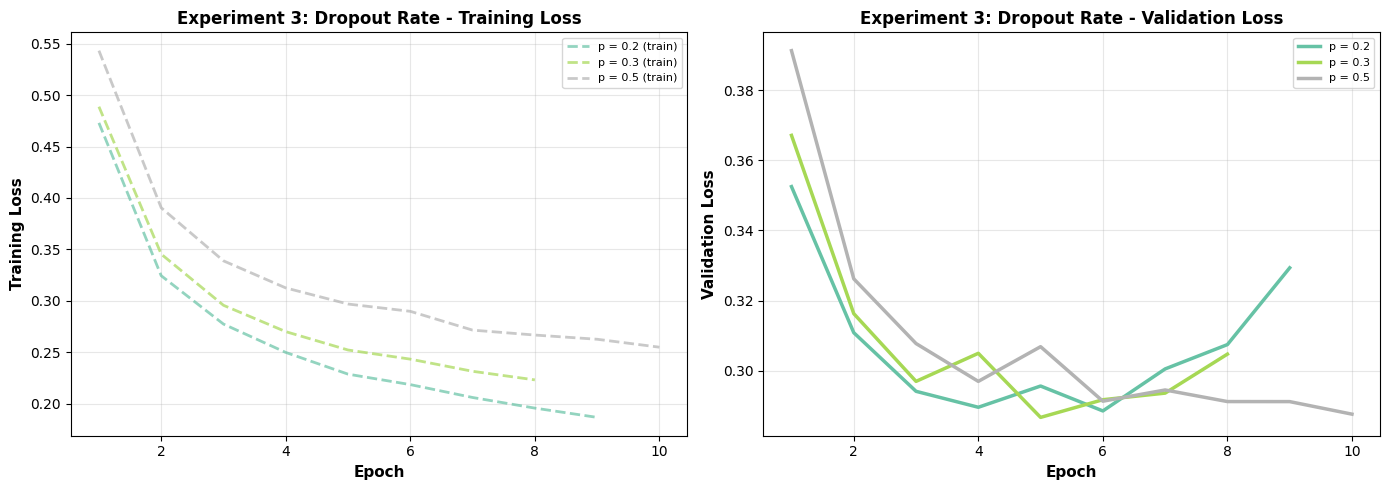


                         EXPERIMENT 3: DROPOUT RATE RESULTS                          
        Best Val Loss Test Accuracy Train Acc Val Acc     Params
p = 0.2        0.2886        0.8792    0.9602  0.8846  5,218,945
p = 0.3        0.2868        0.8780    0.9384  0.8756  5,218,945
p = 0.5        0.2877        0.8847    0.9365  0.8838  5,218,945

✓ Best dropout rate: p = 0.3
  Test Accuracy: 0.8780
  Value: 0.3 (optimal regularization)
✓ Experiment 3 results persisted to ..\results\ablation_results.pkl


In [10]:

# ============================================================================
# EXPERIMENT 3: DROPOUT RATE
# ============================================================================
# Use best depth + best embedding dim from Exp 1 & 2, vary dropout
# Controlled: embed_dim from Exp 2, hidden_dims from Exp 1

print("\n" + "="*70)
print("EXPERIMENT 3: DROPOUT RATE ANALYSIS")
print("="*70)
print("\nComparing dropout rates for regularization:")
print("  - p = 0.2 (light regularization)")
print("  - p = 0.3 (moderate regularization)")
print("  - p = 0.5 (heavy regularization)")
print("\nFixed hyperparameters:")
print(f"  - embed_dim: {best_embed_dim} (best from Exp 2)")
print(f"  - hidden_dims: {best_depth_config['hidden_dims']} (best from Exp 1)")
print("  - epochs: 10\n")

# Define dropout configurations
dropout_configs = {
    'p = 0.2': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.2},
    'p = 0.3': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.3},
    'p = 0.5': {'embed_dim': best_embed_dim, 'hidden_dims': best_depth_config['hidden_dims'], 'dropout': 0.5},
}

# Note: Parameter count is identical for all dropout configs
print("Parameter Count (constant across all dropout rates):")
print("-" * 50)
model = MLPClassifier(
    vocab_size=len(vocab_builder),
    embedding_dim=best_embed_dim,
    hidden_dims=best_depth_config['hidden_dims'],
    dropout=0.3  # dropout doesn't affect param count
)
params = count_params(model)
print(f"  All configs: {params:>10,} params\n")

# Train all dropout configurations
print("-"*70)
print("Training dropout configurations...")
print("-"*70)

dropout_histories = {}
dropout_results = {}
dropout_models = {}

# Save names for each config
dropout_save_names = ['mlp_dropout02', 'mlp_dropout03', 'mlp_dropout05']

for (name, cfg), save_name in zip(dropout_configs.items(), dropout_save_names):
    print(f'\n[Training] {name}')
    print(f"  Config: embed_dim={cfg['embed_dim']}, hidden_dims={cfg['hidden_dims']}, dropout={cfg['dropout']}")
    
    hist, best_val_loss, test_acc, n_params, model = train_model(cfg, num_epochs=NUM_EPOCHS, device=device, model_save_name=save_name)
    
    dropout_histories[name] = hist
    dropout_results[name] = {
        'best_val_loss': best_val_loss,
        'test_acc': test_acc,
        'train_acc': hist['train_acc'],
        'val_acc': hist['val_acc'],
        'params': n_params
    }
    dropout_models[name] = model
    
    print(f"  ✓ Result: Val Loss={best_val_loss:.4f}, Test Acc={test_acc:.4f}, Train Acc={hist['train_acc']:.4f}, Val Acc={hist['val_acc']:.4f}")

# Visualize results
plot_loss_accuracy_curves(dropout_histories, title_prefix='Experiment 3: Dropout Rate')

# Print results table
print_results_table(dropout_results, title='EXPERIMENT 3: DROPOUT RATE RESULTS')

# Identify best configuration
best_dropout_name = min(dropout_results, key=lambda x: dropout_results[x]['best_val_loss'])
best_dropout_config = dropout_configs[best_dropout_name]
best_dropout = best_dropout_config['dropout']
print(f"✓ Best dropout rate: {best_dropout_name}")
print(f"  Test Accuracy: {dropout_results[best_dropout_name]['test_acc']:.4f}")
print(f"  Value: {best_dropout} (optimal regularization)")

# Persist Experiment 3 results so Summary can load later
import pickle
result_cache_path = Path('../results/ablation_results.pkl')
if result_cache_path.exists():
    with open(result_cache_path, 'rb') as f:
        cache = pickle.load(f)
else:
    cache = {}
cache['dropout_results'] = dropout_results
cache['best_dropout'] = best_dropout
with open(result_cache_path, 'wb') as f:
    pickle.dump(cache, f)
print(f"✓ Experiment 3 results persisted to {result_cache_path}")


## Summary: Comprehensive Results & Analysis

Aggregate findings from all three experiments with optimal configuration recommendations

In [12]:

print("\n" + "="*80)
print("COMPREHENSIVE ABLATION STUDY SUMMARY")
print("="*80)

# Ensure experiment results are available
required_names = ['depth_results', 'embed_results', 'dropout_results']
missing = [n for n in required_names if n not in globals()]
if missing:
    # Try loading from persisted results
    import pickle
    cache_path = Path('../results/ablation_results.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)
        for n in missing:
            if n in cache:
                globals()[n] = cache[n]
        if 'best_embed_dim' in cache:
            best_embed_dim = cache['best_embed_dim']
        if 'best_dropout' in cache:
            best_dropout = cache['best_dropout']
        if 'best_depth_config' in cache:
            best_depth_config = cache['best_depth_config']
        missing = [n for n in required_names if n not in globals()]

if missing:
    raise NameError(
        "Missing required experiment variables: {}.\n".format(', '.join(missing)) +
        "Please run Experiment 1, 2, and 3 cells first (or rerun notebook sequentially) before Summary."
    )

# Combine all results
all_results = {
    **{f'[Depth] {k}': v   for k, v in depth_results.items()},
    **{f'[Embed] {k}': v   for k, v in embed_results.items()},
    **{f'[Drop]  {k}': v   for k, v in dropout_results.items()},
}

# Create summary dataframe
df_summary = pd.DataFrame(all_results).T
df_summary.columns = ['Best Val Loss', 'Test Accuracy', 'Train Acc', 'Val Acc', 'Params']
df_summary = df_summary.sort_values('Test Accuracy', ascending=False)

print("\nAll Configurations (sorted by Test Accuracy):")
print("-" * 80)
print(df_summary.to_string())

# Extract key insights
best_config_name = df_summary.index[0]
best_test_acc = df_summary.iloc[0]['Test Accuracy']
best_val_loss = df_summary.iloc[0]['Best Val Loss']

print(f"\n{'='*80}")
print("KEY FINDINGS")
print(f"{'='*80}")

print(f"\n1. BEST OVERALL CONFIGURATION")
print(f"   Config: {best_config_name}")
print(f"   Test Accuracy: {best_test_acc:.4f}")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Parameters: {int(df_summary.iloc[0]['Params']):,}")

# Experiment 1 insights
print(f"\n2. NETWORK DEPTH FINDINGS (Experiment 1)")
depth_accs = [depth_results[k]['test_acc'] for k in depth_results.keys()]
best_depth_acc = max(depth_accs)
worst_depth_acc = min(depth_accs)
print(f"   Best:  {best_depth_acc:.4f}")
print(f"   Worst: {worst_depth_acc:.4f}")
print(f"   Range: {best_depth_acc - worst_depth_acc:.4f}")
print(f"   Conclusion: {'Single layer sufficient' if list(depth_results.keys())[0] in [k for k, v in depth_results.items() if v['test_acc'] >= max(depth_accs) - 0.001] else 'Deeper networks better'}")

# Experiment 2 insights
print(f"\n3. EMBEDDING DIMENSION FINDINGS (Experiment 2)")
embed_accs = [embed_results[k]['test_acc'] for k in embed_results.keys()]
best_embed_idx = embed_accs.index(max(embed_accs))
embed_dims_sorted = sorted(embed_results.keys(), key=lambda x: embed_results[x]['test_acc'], reverse=True)
print(f"   Ranking (by test accuracy):")
for i, name in enumerate(embed_dims_sorted, 1):
    print(f"     {i}. {name:<15} → {embed_results[name]['test_acc']:.4f}")

# Experiment 3 insights
print(f"\n4. DROPOUT RATE FINDINGS (Experiment 3)")
dropout_accs = [dropout_results[k]['test_acc'] for k in dropout_results.keys()]
best_dropout_idx = dropout_accs.index(max(dropout_accs))
dropout_sorted = sorted(dropout_results.keys(), key=lambda x: dropout_results[x]['test_acc'], reverse=True)
print(f"   Ranking (by test accuracy):")
for i, name in enumerate(dropout_sorted, 1):
    print(f"     {i}. {name:<15} → {dropout_results[name]['test_acc']:.4f}")

print(f"\n5. PARAMETER EFFICIENCY")
# Find the best accuracy with fewest parameters
sorted_by_acc = sorted(all_results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
best_efficient = min(sorted_by_acc[:3], key=lambda x: x[1]['params'])
print(f"   Most efficient best-3 config: {best_efficient[0]}")
print(f"   Accuracy: {best_efficient[1]['test_acc']:.4f}, Params: {int(best_efficient[1]['params']):,}")

print(f"\n{'='*80}")
print("RECOMMENDATIONS FOR PART C (RNN COMPARISON)")
print(f"{'='*80}")
print(f"\nUse this best MLP configuration as baseline for RNN comparison:")
print(f"  - Embed Dim: {best_embed_dim}")
print(f"  - Hidden Dims: {best_depth_config['hidden_dims']}")
print(f"  - Dropout: {best_dropout}")
print(f"  - Best Test Accuracy: {best_test_acc:.4f}")
print(f"\nThis ensures fair comparison in notebook 03_rnn.ipynb")
print(f"{'='*80}\n")



COMPREHENSIVE ABLATION STUDY SUMMARY

All Configurations (sorted by Test Accuracy):
--------------------------------------------------------------------------------
                                Best Val Loss  Test Accuracy  Train Acc  Val Acc     Params
[Embed] d_e = 64                     0.289502         0.8872   0.945286   0.8850  1354369.0
[Depth] 2-layers [256,256]           0.287805         0.8859   0.951314   0.8844  2659073.0
[Embed] d_e = 128                    0.288644         0.8854   0.951143   0.8824  2642561.0
[Depth] 1-layer  [512]               0.285302         0.8851   0.946914   0.8856  2626561.0
[Depth] 3-layers [128,256,128]       0.284757         0.8848   0.944257   0.8874  2642561.0
[Drop]  p = 0.5                      0.287678         0.8847   0.936543   0.8838  5218945.0
[Embed] d_e = 256                    0.288347         0.8799   0.940686   0.8816  5218945.0
[Drop]  p = 0.2                      0.288596         0.8792   0.960171   0.8846  5218945.0
[Drop]


GENERATING COMPREHENSIVE COMPARATIVE VISUALIZATIONS


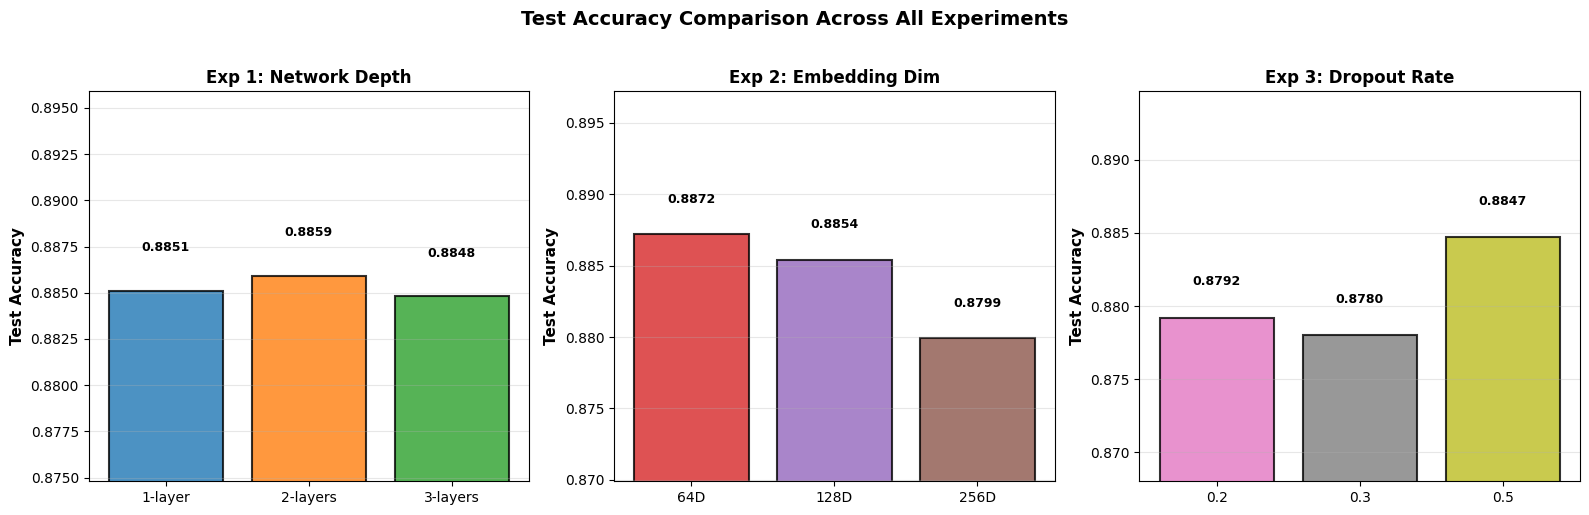

✓ Test accuracy comparison saved


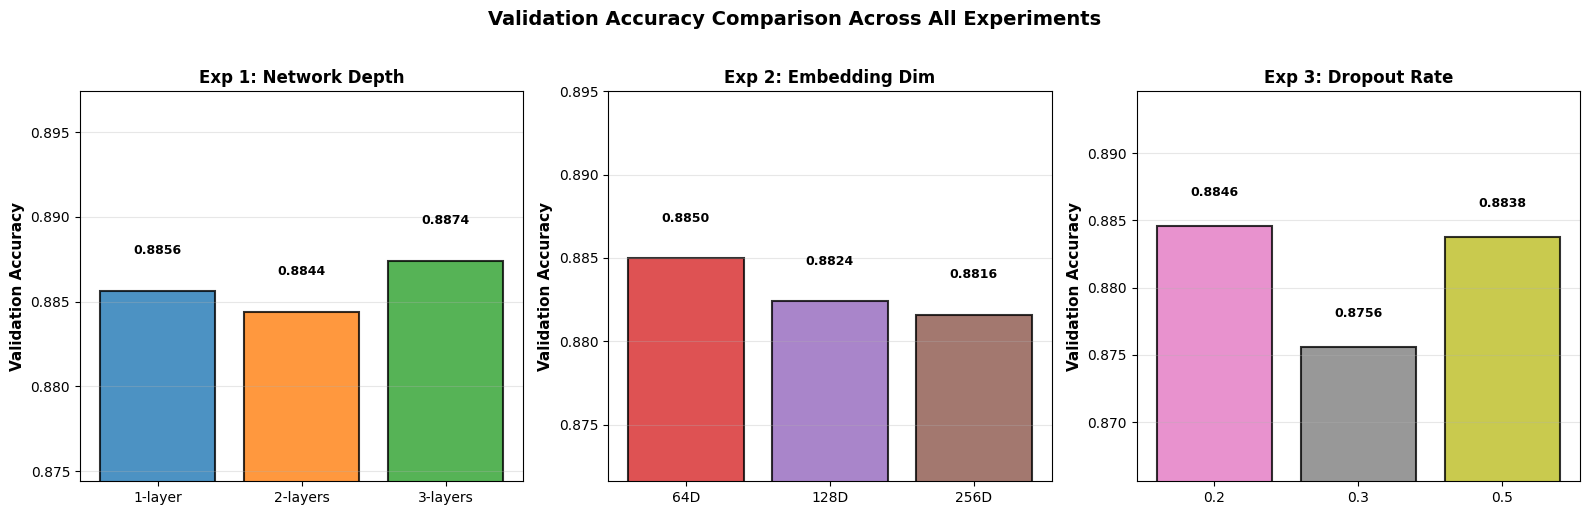

✓ Validation accuracy comparison saved


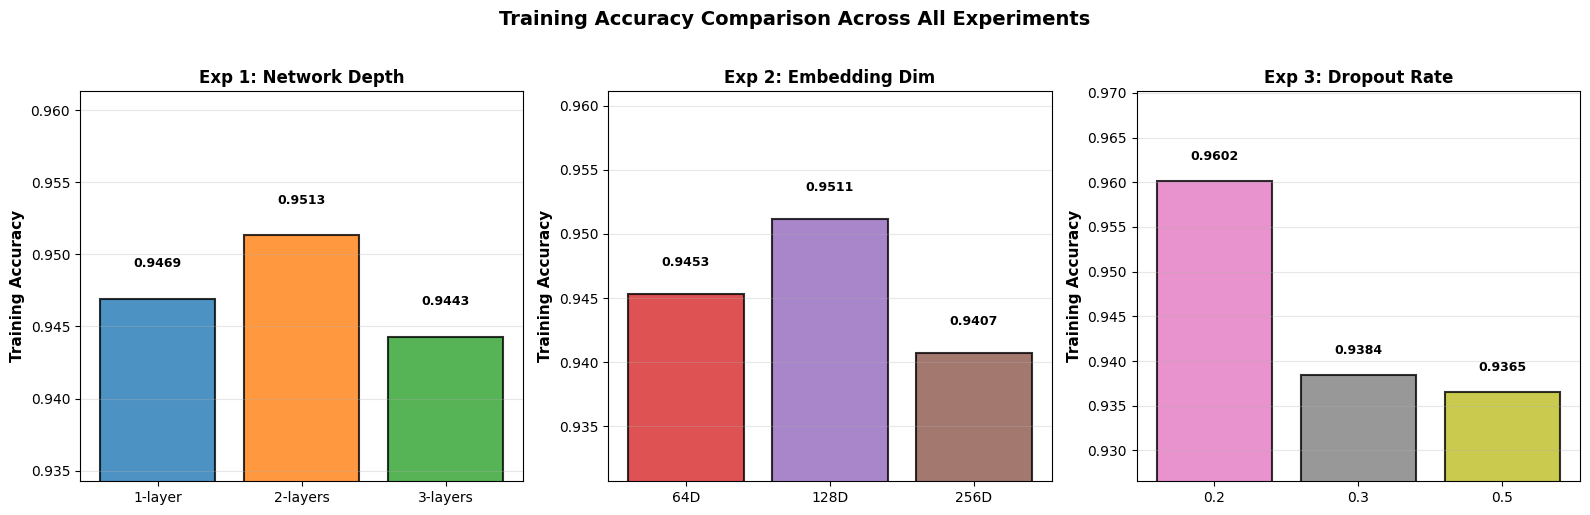

✓ Training accuracy comparison saved


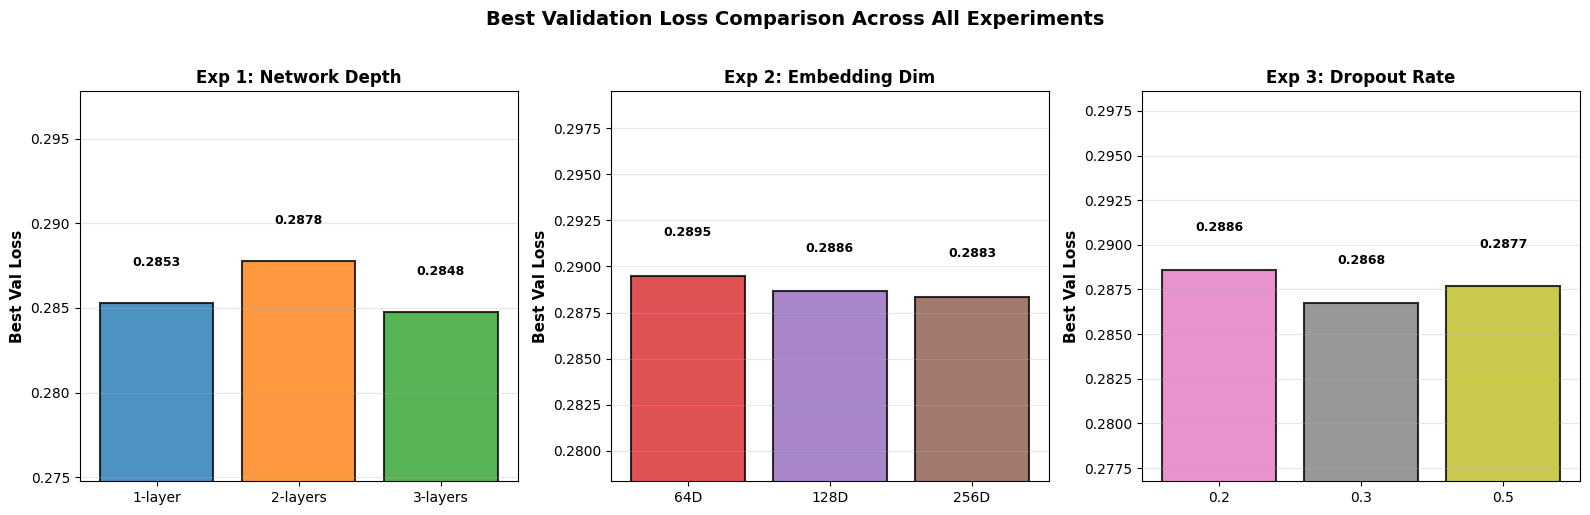

✓ Validation loss comparison saved

✓ All comparative visualizations generated and saved


In [13]:

# ============================================================================
# COMPARATIVE VISUALIZATIONS - SEPARATE CHARTS FOR CLARITY
# ============================================================================

print("\n" + "="*70)
print("GENERATING COMPREHENSIVE COMPARATIVE VISUALIZATIONS")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────
# 1. TEST ACCURACY COMPARISON
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Experiment 1: Network Depth - Test Accuracy
depth_names = list(depth_results.keys())
depth_accs = [depth_results[k]['test_acc'] for k in depth_names]
colors1 = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[0].bar(range(len(depth_names)), depth_accs, color=colors1, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(depth_names)))
axes[0].set_xticklabels(['1-layer', '2-layers', '3-layers'], fontsize=10)
axes[0].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Exp 1: Network Depth', fontsize=12, fontweight='bold')
axes[0].set_ylim([min(depth_accs) - 0.01, max(depth_accs) + 0.01])
for i, acc in enumerate(depth_accs):
    axes[0].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Experiment 2: Embedding Dimension - Test Accuracy
embed_names = list(embed_results.keys())
embed_accs = [embed_results[k]['test_acc'] for k in embed_names]
colors2 = ['#d62728', '#9467bd', '#8c564b']
axes[1].bar(range(len(embed_names)), embed_accs, color=colors2, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xticks(range(len(embed_names)))
axes[1].set_xticklabels(['64D', '128D', '256D'], fontsize=10)
axes[1].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Exp 2: Embedding Dim', fontsize=12, fontweight='bold')
axes[1].set_ylim([min(embed_accs) - 0.01, max(embed_accs) + 0.01])
for i, acc in enumerate(embed_accs):
    axes[1].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Experiment 3: Dropout Rate - Test Accuracy
dropout_names = list(dropout_results.keys())
dropout_accs = [dropout_results[k]['test_acc'] for k in dropout_names]
colors3 = ['#e377c2', '#7f7f7f', '#bcbd22']
axes[2].bar(range(len(dropout_names)), dropout_accs, color=colors3, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[2].set_xticks(range(len(dropout_names)))
axes[2].set_xticklabels(['0.2', '0.3', '0.5'], fontsize=10)
axes[2].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[2].set_title('Exp 3: Dropout Rate', fontsize=12, fontweight='bold')
axes[2].set_ylim([min(dropout_accs) - 0.01, max(dropout_accs) + 0.01])
for i, acc in enumerate(dropout_accs):
    axes[2].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Test Accuracy Comparison Across All Experiments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ablation_test_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Test accuracy comparison saved")

# ─────────────────────────────────────────────────────────────────────────
# 2. VALIDATION ACCURACY COMPARISON
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Experiment 1: Network Depth - Val Accuracy
depth_val_accs = [depth_results[k]['val_acc'] for k in depth_names]
axes[0].bar(range(len(depth_names)), depth_val_accs, color=colors1, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(depth_names)))
axes[0].set_xticklabels(['1-layer', '2-layers', '3-layers'], fontsize=10)
axes[0].set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Exp 1: Network Depth', fontsize=12, fontweight='bold')
axes[0].set_ylim([min(depth_val_accs) - 0.01, max(depth_val_accs) + 0.01])
for i, acc in enumerate(depth_val_accs):
    axes[0].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Experiment 2: Embedding Dimension - Val Accuracy
embed_val_accs = [embed_results[k]['val_acc'] for k in embed_names]
axes[1].bar(range(len(embed_names)), embed_val_accs, color=colors2, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xticks(range(len(embed_names)))
axes[1].set_xticklabels(['64D', '128D', '256D'], fontsize=10)
axes[1].set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Exp 2: Embedding Dim', fontsize=12, fontweight='bold')
axes[1].set_ylim([min(embed_val_accs) - 0.01, max(embed_val_accs) + 0.01])
for i, acc in enumerate(embed_val_accs):
    axes[1].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Experiment 3: Dropout Rate - Val Accuracy
dropout_val_accs = [dropout_results[k]['val_acc'] for k in dropout_names]
axes[2].bar(range(len(dropout_names)), dropout_val_accs, color=colors3, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[2].set_xticks(range(len(dropout_names)))
axes[2].set_xticklabels(['0.2', '0.3', '0.5'], fontsize=10)
axes[2].set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold')
axes[2].set_title('Exp 3: Dropout Rate', fontsize=12, fontweight='bold')
axes[2].set_ylim([min(dropout_val_accs) - 0.01, max(dropout_val_accs) + 0.01])
for i, acc in enumerate(dropout_val_accs):
    axes[2].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Validation Accuracy Comparison Across All Experiments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ablation_val_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Validation accuracy comparison saved")

# ─────────────────────────────────────────────────────────────────────────
# 3. TRAINING ACCURACY COMPARISON
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Experiment 1: Network Depth - Train Accuracy
depth_train_accs = [depth_results[k]['train_acc'] for k in depth_names]
axes[0].bar(range(len(depth_names)), depth_train_accs, color=colors1, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(depth_names)))
axes[0].set_xticklabels(['1-layer', '2-layers', '3-layers'], fontsize=10)
axes[0].set_ylabel('Training Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Exp 1: Network Depth', fontsize=12, fontweight='bold')
axes[0].set_ylim([min(depth_train_accs) - 0.01, max(depth_train_accs) + 0.01])
for i, acc in enumerate(depth_train_accs):
    axes[0].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Experiment 2: Embedding Dimension - Train Accuracy
embed_train_accs = [embed_results[k]['train_acc'] for k in embed_names]
axes[1].bar(range(len(embed_names)), embed_train_accs, color=colors2, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xticks(range(len(embed_names)))
axes[1].set_xticklabels(['64D', '128D', '256D'], fontsize=10)
axes[1].set_ylabel('Training Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Exp 2: Embedding Dim', fontsize=12, fontweight='bold')
axes[1].set_ylim([min(embed_train_accs) - 0.01, max(embed_train_accs) + 0.01])
for i, acc in enumerate(embed_train_accs):
    axes[1].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Experiment 3: Dropout Rate - Train Accuracy
dropout_train_accs = [dropout_results[k]['train_acc'] for k in dropout_names]
axes[2].bar(range(len(dropout_names)), dropout_train_accs, color=colors3, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[2].set_xticks(range(len(dropout_names)))
axes[2].set_xticklabels(['0.2', '0.3', '0.5'], fontsize=10)
axes[2].set_ylabel('Training Accuracy', fontsize=11, fontweight='bold')
axes[2].set_title('Exp 3: Dropout Rate', fontsize=12, fontweight='bold')
axes[2].set_ylim([min(dropout_train_accs) - 0.01, max(dropout_train_accs) + 0.01])
for i, acc in enumerate(dropout_train_accs):
    axes[2].text(i, acc + 0.002, f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Training Accuracy Comparison Across All Experiments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ablation_train_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training accuracy comparison saved")

# ─────────────────────────────────────────────────────────────────────────
# 4. BEST VALIDATION LOSS COMPARISON
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Experiment 1: Network Depth - Val Loss
depth_val_losses = [depth_results[k]['best_val_loss'] for k in depth_names]
axes[0].bar(range(len(depth_names)), depth_val_losses, color=colors1, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_xticks(range(len(depth_names)))
axes[0].set_xticklabels(['1-layer', '2-layers', '3-layers'], fontsize=10)
axes[0].set_ylabel('Best Val Loss', fontsize=11, fontweight='bold')
axes[0].set_title('Exp 1: Network Depth', fontsize=12, fontweight='bold')
axes[0].set_ylim([min(depth_val_losses) - 0.01, max(depth_val_losses) + 0.01])
for i, loss in enumerate(depth_val_losses):
    axes[0].text(i, loss + 0.002, f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Experiment 2: Embedding Dimension - Val Loss
embed_val_losses = [embed_results[k]['best_val_loss'] for k in embed_names]
axes[1].bar(range(len(embed_names)), embed_val_losses, color=colors2, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_xticks(range(len(embed_names)))
axes[1].set_xticklabels(['64D', '128D', '256D'], fontsize=10)
axes[1].set_ylabel('Best Val Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Exp 2: Embedding Dim', fontsize=12, fontweight='bold')
axes[1].set_ylim([min(embed_val_losses) - 0.01, max(embed_val_losses) + 0.01])
for i, loss in enumerate(embed_val_losses):
    axes[1].text(i, loss + 0.002, f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Experiment 3: Dropout Rate - Val Loss
dropout_val_losses = [dropout_results[k]['best_val_loss'] for k in dropout_names]
axes[2].bar(range(len(dropout_names)), dropout_val_losses, color=colors3, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[2].set_xticks(range(len(dropout_names)))
axes[2].set_xticklabels(['0.2', '0.3', '0.5'], fontsize=10)
axes[2].set_ylabel('Best Val Loss', fontsize=11, fontweight='bold')
axes[2].set_title('Exp 3: Dropout Rate', fontsize=12, fontweight='bold')
axes[2].set_ylim([min(dropout_val_losses) - 0.01, max(dropout_val_losses) + 0.01])
for i, loss in enumerate(dropout_val_losses):
    axes[2].text(i, loss + 0.002, f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Best Validation Loss Comparison Across All Experiments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/ablation_val_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Validation loss comparison saved")
print("\n" + "="*70)
print("✓ All comparative visualizations generated and saved")
print("="*70)
